# Blinkit Data Analytics — Order arrival by hour and weekday
DuckDB SQL + Python | Yash Prajapati

## 1. Setup

### 1.1 Libraries

In [1]:
import warnings, math, textwrap
warnings.filterwarnings('ignore')
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams.update({'figure.figsize':(10,4.5),'axes.grid':True,'grid.alpha':.25,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})
print('duckdb', duckdb.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

duckdb 1.5.5 | pandas 3.0.2 | numpy 2.4.4


### 1.2 Load cleaned workbook

In [2]:
XLSX = 'data/Blinkit_analysis_new.xlsx'
book = pd.read_excel(XLSX, sheet_name=None)
geo = pd.read_csv('data/city_state_zone.csv')
for name, df in book.items():
    print(f'{name:28s} {df.shape[0]:>6,} rows  {df.shape[1]:>3} cols')

Data_Quality_Report              46 rows    3 cols
Orders_Customer_Info          5,000 rows   16 cols
Orders_Raw_Archive            5,000 rows   23 cols
Order_Line_Items              5,000 rows   14 cols
Delivery_Performance          5,000 rows    8 cols
Customer_Feedback             5,000 rows    8 cols
Customers                     2,500 rows   11 cols
Products                        268 rows   10 cols
Inventory_Analysis              268 rows   18 cols
Data_Dictionary                  44 rows    4 cols
Reference_Parameters             11 rows    5 cols
Relational_Diagram                0 rows    0 cols
Pivot_Payment_Method              7 rows    7 cols
Pivot_Customer_Segment            7 rows    5 cols
Pivot_Category_Sales             14 rows    4 cols
Pivot_Monthly_Trend              24 rows    6 cols
Pivot_Area_Delivery              23 rows    6 cols
Pivot_Inventory_Movement          6 rows    7 cols
Pivot_Category_Stock             14 rows    8 cols


### 1.3 Create DuckDB database and load tables

In [3]:
con = duckdb.connect('blinkit.duckdb')
load = {'orders_src':'Orders_Raw_Archive','items_src':'Order_Line_Items','delivery_src':'Delivery_Performance',
        'feedback_src':'Customer_Feedback','customers_src':'Customers','products_src':'Products','inventory_src':'Inventory_Analysis'}
for tbl, sheet in load.items():
    df = book[sheet].copy()
    df.columns = [c.strip() for c in df.columns]
    con.register('tmp_df', df)
    con.execute(f'CREATE OR REPLACE TABLE {tbl} AS SELECT * FROM tmp_df')
con.register('geo_df', geo)
con.execute('CREATE OR REPLACE TABLE geo AS SELECT * FROM geo_df')
con.execute("SELECT table_name, estimated_size FROM duckdb_tables() ORDER BY table_name").df()

,table_name,estimated_size
0,customers_src,2500
1,delivery_src,5000
2,feedback_src,5000
3,geo,316
4,inventory_src,268
5,items_src,5000
6,orders_src,5000
7,products_src,268


### 1.4 Typed analysis views

In [4]:
con.execute('''
CREATE OR REPLACE VIEW orders AS
SELECT order_id, customer_id,
       strptime(order_date, '%d-%m-%Y %H:%M')              AS order_ts,
       CAST(strptime(order_date, '%d-%m-%Y %H:%M') AS DATE) AS order_date,
       strptime(promised_delivery_time, '%d-%m-%Y %H:%M')   AS promised_ts,
       strptime(actual_delivery_time,  '%d-%m-%Y %H:%M')    AS actual_ts,
       delivery_status, order_total, payment_method, delivery_partner_id, store_id,
       CAST(delivery_time_minutes AS INTEGER)               AS delay_min,
       distance_km, reasons_if_delayed, customer_name,
       trim(area) AS area, pincode, customer_segment,
       CAST(registration_date AS DATE)                      AS registration_date,
       order_day_of_week, order_time_slot, order_value_segment,
       CASE WHEN is_weekend = 'Yes' THEN 1 ELSE 0 END       AS is_weekend
FROM orders_src ''')

con.execute('''
CREATE OR REPLACE VIEW items AS
SELECT order_id, product_id, quantity, unit_price, product_name, category, brand,
       price, mrp, margin_percentage, shelf_life_days, min_stock_level, max_stock_level, line_total,
       line_total * margin_percentage / 100.0 AS margin_value
FROM items_src ''')

con.execute('''
CREATE OR REPLACE VIEW feedback AS
SELECT feedback_id, order_id, customer_id, rating, feedback_category, sentiment,
       CAST(feedback_date AS DATE) AS feedback_date
FROM feedback_src ''')

con.execute('''
CREATE OR REPLACE VIEW f_sales AS
SELECT o.order_id, o.customer_id, o.order_ts, o.order_date,
       date_trunc('month', o.order_date)  AS order_month,
       extract(hour FROM o.order_ts)      AS order_hour,
       o.order_day_of_week, o.is_weekend, o.order_time_slot, o.order_value_segment,
       o.payment_method, o.customer_segment, o.registration_date, o.customer_name,
       o.area, g.state, g.zone, g.city_tier,
       i.product_id, i.product_name, i.category, i.brand,
       i.quantity, i.line_total AS revenue, i.margin_value, i.margin_percentage,
       i.price, i.mrp, i.shelf_life_days,
       o.delay_min, o.distance_km, o.delivery_status,
       CASE WHEN o.delivery_status = 'On Time' THEN 1 ELSE 0 END AS is_on_time_status,
       CASE WHEN o.delay_min > 0 THEN 1 ELSE 0 END               AS is_late_minutes,
       f.rating, f.sentiment, f.feedback_category
FROM orders o
JOIN items i    ON i.order_id = o.order_id
LEFT JOIN geo g ON g.area     = o.area
LEFT JOIN feedback f ON f.order_id = o.order_id ''')

con.execute('SELECT COUNT(*) AS fact_rows, COUNT(DISTINCT order_id) AS orders, MIN(order_date) AS first_day, MAX(order_date) AS last_day FROM f_sales').df()

,fact_rows,orders,first_day,last_day
0,5000,5000,2023-03-16,2024-11-04


### 1.5 Query helper

In [5]:
def q(sql, con=con):
    return con.execute(textwrap.dedent(sql)).df()

def pct(x, n):
    return round(100.0 * x / n, 2) if n else 0.0

q('SELECT COUNT(*) AS rows_in_fact_view FROM f_sales')

,rows_in_fact_view
0,5000


### Chart colours

In [6]:
GREEN, GOLD, BLUE, RED, GREY = '#0B7A2A', '#E0A31C', '#2A6FD0', '#CC3B37', '#8A938D'

## 12. Time of day and week

### 12.1 Orders by hour

In [7]:
q('''
SELECT order_hour, COUNT(*) AS orders, round(SUM(revenue), 0) AS revenue,
       round(AVG(revenue), 0) AS aov,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct,
       round(AVG(delay_min), 2) AS avg_minutes
FROM f_sales GROUP BY order_hour ORDER BY order_hour ''')

,order_hour,orders,revenue,aov,on_time_pct,avg_minutes
0,0,221,"234,892.00","1,063.00",68.78,4.28
1,1,209,"237,661.00","1,137.00",70.33,4.30
2,2,200,"179,612.00",898.00,68.50,5.52
3,3,189,"176,154.00",932.00,68.25,4.01
4,4,215,"224,148.00","1,043.00",66.51,4.69
5,5,216,"205,284.00",950.00,69.91,4.47
6,6,204,"202,774.00",994.00,69.12,4.83
7,7,217,"219,148.00","1,010.00",68.20,4.71
8,8,240,"240,608.00","1,003.00",72.08,4.03
9,9,181,"193,562.00","1,069.00",70.72,4.24


### 12.2 Time slots corrected for slot length

In [8]:
q('''
WITH s AS (
  SELECT order_time_slot, COUNT(*) AS orders, SUM(revenue) AS revenue,
         COUNT(DISTINCT order_hour) AS hours_in_slot FROM f_sales GROUP BY 1)
SELECT order_time_slot AS slot, hours_in_slot, orders,
       round(100.0 * orders / SUM(orders) OVER (), 2) AS order_share_pct,
       round(orders * 1.0 / hours_in_slot, 1) AS orders_per_hour,
       round(revenue, 0) AS revenue,
       round(revenue / hours_in_slot, 0) AS revenue_per_hour
FROM s ORDER BY orders_per_hour DESC ''')

,slot,hours_in_slot,orders,order_share_pct,orders_per_hour,revenue,revenue_per_hour
0,Evening,4,885,17.70,221.30,"840,358.00","210,090.00"
1,Morning,7,1445,28.90,206.40,"1,451,880.00","207,411.00"
2,Afternoon,5,1030,20.60,206.00,"1,017,485.00","203,497.00"
3,Night,8,1640,32.80,205.00,"1,662,692.00","207,837.00"


### 12.3 Orders by day of week

In [9]:
q('''
SELECT order_day_of_week AS day, COUNT(*) AS orders,
       COUNT(DISTINCT order_date) AS calendar_days,
       round(COUNT(*) * 1.0 / COUNT(DISTINCT order_date), 1) AS orders_per_day,
       round(SUM(revenue), 0) AS revenue, round(AVG(revenue), 0) AS aov,
       round(100.0 * COUNT(*) FILTER (WHERE is_on_time_status = 1) / COUNT(*), 2) AS on_time_pct
FROM f_sales GROUP BY 1 ORDER BY orders_per_day DESC ''')

,day,orders,calendar_days,orders_per_day,revenue,aov,on_time_pct
0,Wednesday,744,85,8.80,"753,019.00","1,012.00",68.82
1,Thursday,720,86,8.40,"716,916.00",996.00,69.17
2,Sunday,723,86,8.40,"694,407.00",960.00,69.99
3,Tuesday,705,85,8.30,"735,501.00","1,043.00",69.65
4,Friday,715,86,8.30,"678,558.00",949.00,69.93
5,Saturday,706,86,8.20,"700,108.00",992.00,70.82
6,Monday,687,86,8.00,"693,907.00","1,010.00",67.39


### 12.4 Weekday against weekend

In [10]:
wk = q('''
SELECT order_date, is_weekend, COUNT(*) AS orders, SUM(revenue) AS revenue
FROM f_sales GROUP BY 1, 2 ''')
u = stats.mannwhitneyu(wk[wk.is_weekend == 0].orders, wk[wk.is_weekend == 1].orders)
t = stats.ttest_ind(wk[wk.is_weekend == 0].orders, wk[wk.is_weekend == 1].orders, equal_var=False)
summary = wk.groupby('is_weekend').agg(days=('order_date','nunique'), orders_per_day=('orders','mean'),
                                       revenue_per_day=('revenue','mean')).round(2)
summary.index = ['Weekday','Weekend']
print(summary)
pd.DataFrame([{'test':'Mann-Whitney U (orders per day)','statistic':round(u.statistic,1),'p_value':round(u.pvalue,4)},
              {'test':"Welch t-test (orders per day)",'statistic':round(t.statistic,4),'p_value':round(t.pvalue,4)}])

         days  orders_per_day  revenue_per_day
Weekday   428            8.34         8,359.58
Weekend   172            8.31         8,107.64


,test,statistic,p_value
0,Mann-Whitney U (orders per day),"36,897.50",0.96
1,Welch t-test (orders per day),0.13,0.90


### 12.5 Demand map by day and hour

In [11]:
heat = q('''
SELECT order_day_of_week AS day, order_hour, COUNT(*) AS orders FROM f_sales GROUP BY 1, 2 ''')
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat_pivot = heat.pivot(index='day', columns='order_hour', values='orders').reindex(order_days).fillna(0).astype(int)
heat_pivot

order_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
day,,,,,,,,,,,,,,,,,,,,,,,,
Monday,32,39,24,34,28,28,31,31,29,31,10,26,30,27,20,28,26,34,27,32,30,29,32,29
Tuesday,38,24,35,29,22,34,26,28,25,18,36,23,32,31,22,26,35,20,27,42,40,31,34,27
Wednesday,20,26,35,26,27,33,27,29,33,27,31,36,38,35,36,34,27,34,33,30,26,34,34,33
Thursday,37,33,22,21,35,34,29,29,41,17,26,22,23,38,33,33,23,36,39,31,32,24,21,41
Friday,37,29,27,26,30,25,30,36,35,33,31,18,19,37,31,24,25,28,38,37,33,28,27,31
Saturday,25,31,27,30,36,31,32,33,40,28,30,28,28,32,19,34,28,28,27,32,33,26,23,25
Sunday,32,27,30,23,37,31,29,31,37,27,39,31,23,39,36,25,33,24,35,24,33,23,27,27


### 12.6 Three-hour rolling demand window

In [12]:
q('''
WITH h AS (SELECT order_hour, COUNT(*) AS orders FROM f_sales GROUP BY 1),
w AS (SELECT order_hour, orders,
             SUM(orders) OVER (ORDER BY order_hour ROWS BETWEEN 1 PRECEDING AND 1 FOLLOWING) AS rolling_3h_orders
      FROM h)
SELECT order_hour AS window_centre_hour, orders, rolling_3h_orders,
       RANK() OVER (ORDER BY rolling_3h_orders DESC) AS window_rank
FROM w ORDER BY window_rank LIMIT 8 ''')

,window_centre_hour,orders,rolling_3h_orders,window_rank
0,19,228,681.00,1
1,7,217,661.00,2
2,18,226,658.00,3
3,20,227,650.00,4
4,14,197,640.00,5
5,8,240,638.00,6
6,6,204,637.00,7
7,5,216,635.00,8


## Charts

### 16.5 Demand by day and hour

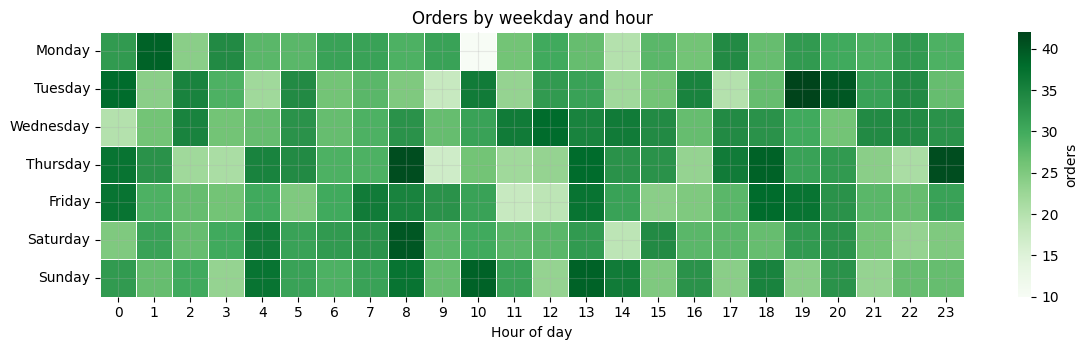

In [13]:
fig, ax = plt.subplots(figsize=(12, 3.6))
sns.heatmap(heat_pivot, cmap='Greens', linewidths=.6, linecolor='white', cbar_kws={'label':'orders'}, ax=ax)
ax.set_title('Orders by weekday and hour'); ax.set_xlabel('Hour of day'); ax.set_ylabel('')
plt.tight_layout(); plt.show()